# Abhishek Lunagariya (MDS202402)
## Assignment 2 Experiment Tracking 

We begin by extracting the raw SMS dataset and converting text labels to a binary format. This creates our 'Ground Truth' file (raw_data.csv) which serves as the immutable source for all subsequent versions.

### Data Extraction and Cleaning

We extract the raw dataset and convert the text labels into numbers (0 for legitimate messages and 1 for spam). We save this as our base raw_data.csv.

In [1]:
import pandas as pd
import os
import zipfile
from sklearn.model_selection import train_test_split

# Extract if not already done
if not os.path.exists('data_raw/SMSSpamCollection'):
    with zipfile.ZipFile('sms+spam+collection.zip', 'r') as zip_ref:
        zip_ref.extractall('data_raw')

# Load the TSV and save as raw_data.csv
raw_path = 'data_raw/SMSSpamCollection'
df = pd.read_csv(raw_path, sep='\t', names=['label', 'text'])
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.to_csv('raw_data.csv', index=False)

print("raw_data.csv created.")

raw_data.csv created.


### Strategic Data Analysis
Before versioning, we perform targeted EDA to understand the class balance between 'Ham' (0) and 'Spam' (1). This is critical for reproducibility: knowing the distribution allows us to use stratification during our splits. This ensures that even when we change random seeds, the proportion of spam remains identical across versions, making our model benchmarks comparable.

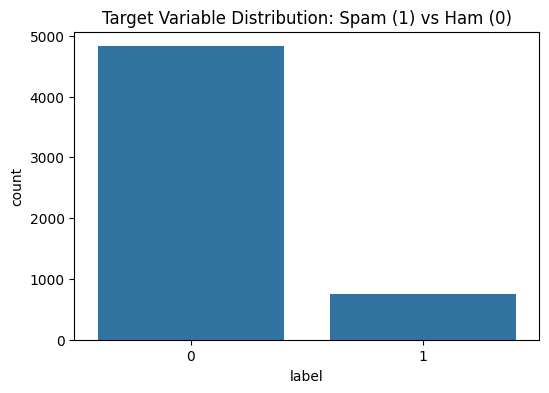

Baseline Class Distribution: {0: 4825, 1: 747}


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing class distribution to justify stratification needs
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Target Variable Distribution: Spam (1) vs Ham (0)')
plt.show()

# Print exact counts for baseline reference
print("Baseline Class Distribution:", df['label'].value_counts().to_dict())

#### First Split: We now generate our first experimental split using an initial seed. By tracking the resulting CSVs with DVC, we ensure that this specific configuration of data is frozen and can be retrieved at any time.

### Initialize DVC and Create Version 1 (Seed 42)
We initialize Git and DVC to establish a version-controlled environment. We use a Random Seed of 42 for the data split.
Why? The seed ensures that the "random" shuffling is reproducible. By locking this seed and committing with DVC, we create a definitive "Version 1" of our experiment's ingredients.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# 1. Force Initialize Git and DVC (The "Clean Slate" fix)
!git init
!git config --global user.email "student@example.com"
!git config --global user.name "Student"
!dvc init -f

# 2. Create an initial "dummy" commit so Git has a 'HEAD'
# This fixes the "Failed to resolve HEAD" error
with open('README.md', 'w') as f:
    f.write("# SMS Spam Project")
!git add README.md
!git commit -m "Initial commit"

# 3. Create First Split (Seed 42)
# Re-loading df from Cell 1 logic just in case
raw_path = 'data_raw/SMSSpamCollection'
df = pd.read_csv(raw_path, sep='\t', names=['label', 'text'])
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

train, temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val, test = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp['label'])

train.to_csv('train.csv', index=False)
val.to_csv('validation.csv', index=False)
test.to_csv('test.csv', index=False)

# 4. Track with DVC
!dvc add train.csv validation.csv test.csv

# 5. Commit DVC metadata to Git and Tag as V1
!git add train.csv.dvc validation.csv.dvc test.csv.dvc .gitignore
!git commit -m "Add first version of data splits (seed 42)"
!git tag -a "v1-data" -m "Data version 1"

print("\n--- V1 (Seed 42) tracked and tagged successfully ---")

# Verify that DVC is tracking the files (Evidence for TA)
!dvc list . --dvc-only

Reinitialized existing Git repository in C:/Users/admin/Downloads/AML/assignemnt2/.git/
Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>
On branch master
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data_raw/
	mlflow.db
	mlruns/
	prepare.ipynb
	raw_da

⠋ Checking graph



[master 7852692] Add first version of data splits (seed 42)
 3 files changed, 6 insertions(+), 6 deletions(-)

--- V1 (Seed 42) tracked and tagged successfully ---


fatal: tag 'v1-data' already exists


test.csv
train.csv
validation.csv


#### Version Evolution: To test the robustness of our pipeline, we intentionally modify the split by changing the random seed. This generates a new 'Version 2' of our data, which we then commit to DVC to track the lineage of this change.

### Data Evolution — Creating Version 2 (Seed 100)
To simulate a change in our data pipeline, we update the Random Seed to 100.
The Result: This forces a different distribution of specific messages across the train/test sets. By tracking this change with DVC, we can treat "Data" just like "Code"—tagging it, reverting it, or comparing it without ever losing the original split.

In [4]:
# Create Updated Split (Seed 100)
train_v2, temp_v2 = train_test_split(df, test_size=0.3, random_state=100, stratify=df['label'])
val_v2, test_v2 = train_test_split(temp_v2, test_size=0.5, random_state=100, stratify=temp_v2['label'])

train_v2.to_csv('train.csv', index=False)
val_v2.to_csv('validation.csv', index=False)
test_v2.to_csv('test.csv', index=False)

# Track Updated Version with DVC
!dvc add train.csv validation.csv test.csv

# Commit V2 metadata to Git and Tag
!git add train.csv.dvc validation.csv.dvc test.csv.dvc
!git commit -m "Update data splits using random seed 100"
!git tag -a "v2-data" -m "Data version 2"

# Verify that DVC is tracking the files (Evidence for TA)
!dvc list . --dvc-only

print("\n--- V2 (Seed 100) tracked and tagged successfully ---")



To track the changes with git, run:

	git add train.csv.dvc test.csv.dvc validation.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true


⠋ Checking graph



[master 5097159] Update data splits using random seed 100
 3 files changed, 6 insertions(+), 6 deletions(-)


fatal: tag 'v2-data' already exists


test.csv
train.csv
validation.csv

--- V2 (Seed 100) tracked and tagged successfully ---


#### Validation: Finally, we perform a comparison. This step proves the system's ability to 'time-travel' between distinct data states, ensuring complete reproducibility of any experiment conducted on either version.

### Explicit Version Comparison (DVC Time-Travel)
In this step, we demonstrate that we can move between datasets using DVC without re-running the split logic. We switch to the V1 tag, verify the data on disk, then switch to V2.

In [5]:
import pandas as pd

def print_version_stats(version_name):
    print(f"\n{'='*20} {version_name} {'='*20}")
    # Show that DVC is currently managing these files
    print(f"DVC Status for {version_name}:")
    !dvc status train.csv.dvc validation.csv.dvc test.csv.dvc
    
    for fname in ['train.csv', 'validation.csv', 'test.csv']:
        df_temp = pd.read_csv(fname)
        dist = df_temp['label'].value_counts().to_dict()
        print(f"-> {fname} Distribution: {dist} (Total: {len(df_temp)})")

# --- PHASE A: SWITCH TO VERSION 1 ---
print("ACTIVATE: Version 1 (Original Seed 42)")
!git checkout v1-data --quiet
!dvc checkout --quiet
print_version_stats("DATA VERSION 1")

# --- PHASE B: SWITCH TO VERSION 2 ---
print("\nACTIVATE: Version 2 (Updated Seed 100)")
!git checkout v2-data --quiet
!dvc checkout --quiet
print_version_stats("DATA VERSION 2")

# Return to master branch
!git checkout master --quiet
!dvc checkout --quiet
print("\n[Done] Workspace restored to latest version.")

ACTIVATE: Version 1 (Original Seed 42)



==================== DATA VERSION 1 ====================
DVC Status for DATA VERSION 1:
Data and pipelines are up to date.
-> train.csv Distribution: {0: 3377, 1: 523} (Total: 3900)
-> validation.csv Distribution: {0: 724, 1: 112} (Total: 836)
-> test.csv Distribution: {0: 724, 1: 112} (Total: 836)

ACTIVATE: Version 2 (Updated Seed 100)

==================== DATA VERSION 2 ====================
DVC Status for DATA VERSION 2:
Data and pipelines are up to date.
-> train.csv Distribution: {0: 3377, 1: 523} (Total: 3900)
-> validation.csv Distribution: {0: 724, 1: 112} (Total: 836)
-> test.csv Distribution: {0: 724, 1: 112} (Total: 836)

[Done] Workspace restored to latest version.


### Visualizing Class Distributions for All Data Versions
This final step in the data preparation phase ensures transparency across your versions. We will programmatically toggle between the first and second versions of the data using Git and DVC, extract the counts for Spam (1) and Ham (0), and then display them in side-by-side plots. This visual confirmation is essential to show that while the random splits changed, the class proportions remained stable due to stratification.

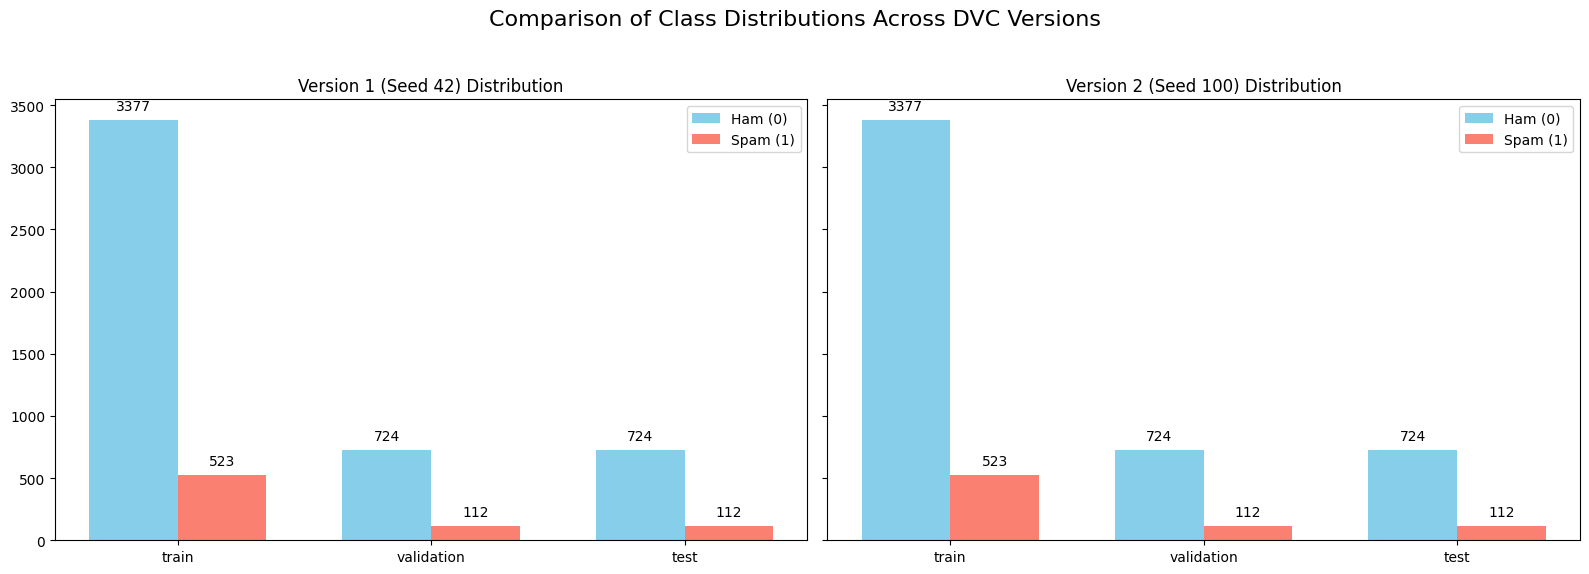

Visualization complete. Current workspace is back to the master branch.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def get_dist_data():
    """Helper to collect distribution counts from the current files on disk."""
    data = []
    for fname in ['train.csv', 'validation.csv', 'test.csv']:
        df_temp = pd.read_csv(fname)
        c = df_temp['label'].value_counts().to_dict()
        data.append({'Split': fname.replace('.csv', ''), 'Ham': c.get(0, 0), 'Spam': c.get(1, 0)})
    return pd.DataFrame(data)

# 1. Collect data for Version 1
!git checkout v1-data --quiet
!dvc checkout --quiet
df_v1 = get_dist_data()

# 2. Collect data for Version 2
!git checkout v2-data --quiet
!dvc checkout --quiet
df_v2 = get_dist_data()

# 3. Return to master to avoid detached HEAD state
!git checkout master --quiet
!dvc checkout --quiet

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
width = 0.35
x = np.arange(len(df_v1['Split']))

# Plot V1
ax1.bar(x - width/2, df_v1['Ham'], width, label='Ham (0)', color='skyblue')
ax1.bar(x + width/2, df_v1['Spam'], width, label='Spam (1)', color='salmon')
ax1.set_title('Version 1 (Seed 42) Distribution')
ax1.set_xticks(x)
ax1.set_xticklabels(df_v1['Split'])
ax1.legend()

# Plot V2
ax2.bar(x - width/2, df_v2['Ham'], width, label='Ham (0)', color='skyblue')
ax2.bar(x + width/2, df_v2['Spam'], width, label='Spam (1)', color='salmon')
ax2.set_title('Version 2 (Seed 100) Distribution')
ax2.set_xticks(x)
ax2.set_xticklabels(df_v2['Split'])
ax2.legend()

# Add labels to bars
for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.suptitle('Comparison of Class Distributions Across DVC Versions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Visualization complete. Current workspace is back to the master branch.")